#### Objectif :

Ce notebook met en place une seconde étape d'analyse, complémentaire au pipeline Morlet exploratoire.

L'idée générale est la suivante :

on utilise Morlet pour repérer de manière exploratoire les bandes et fenêtres fréquentielles potentiellement modulées ;
on revient ensuite au signal continu, que l'on filtre dans des sous-bandes fixes ;
on extrait l'enveloppe d'amplitude par transformée de Hilbert ;
on normalise cette enveloppe à l'échelle de la session ;
on époque autour des stimulations ;
on regroupe les observations par condition cognitive et localité (local / distant) ;
on teste ensuite les courbes temporelles Hilbert, session par session ou pooled across sessions.

Le découpage suit la logique méthodologique inspirée de Vidal et al. (2010), adaptée aux stimulations intracérébrales.

In [1]:
# imports
from pathlib import Path

# import numpy as np
import pandas as pd
import json

from lfp_hilbert_utils import (
    HilbertConfig,
    # build_hilbert_subbands,
    build_main_band_to_subbands,
    prepare_hilbert_session_data,
    run_session_hilbert,
    run_all_sessions_hilbert,
    load_hilbert_session_exports,
    load_hilbert_band_epochs,
)

from lfp_hilbert_stats import (
    HilbertStatsConfig,
    stack_hilbert_band_condition_locality,
    stack_hilbert_band_condition_locality_across_sessions,
    run_hilbert_session_condition_stats,
    run_pooled_hilbert_condition_stats,
    run_all_hilbert_stats,
)

from lfp_preprocess import (
    list_trc_sessions,
    load_bad_channels_table,
)

from lfp_morlet_stats import (
    build_main_condition_index,
    build_cog_subcategory_index,
)

In [2]:
# configuration Hilbert

hilbert_cfg = HilbertConfig(
    root_dir="/home/aube/Documents/article_neuronal_stimic/effets_cog/theta_gamma_cog",
    output_dir="/home/aube/Documents/article_neuronal_stimic/effets_cog/theta_gamma_cog/results_hilbert",

    pre_length=3.0,
    post_length=3.0,
    epsilon=0.1,

    do_notch=True,
    notch_freqs=(50.0, 100.0, 150.0),
    notch_q=30.0,
    do_highpass=True,
    highpass_hz=0.1,

    gamma_low_hz=30.0,
    gamma_high_hz=150.0,
    gamma_step_hz=10.0,

    beta_low_hz = 12.0,
    beta_high_hz = 30.0,
    beta_step_hz = 4.0,

    alpha_low_hz = 8.0,
    alpha_high_hz = 12.0,
    alpha_step_hz = 2.0,

    theta_low_hz=4.0,
    theta_high_hz=8.0,
    theta_step_hz=2.0,

    include_delta=False,
    delta_low_hz=1.0,
    delta_high_hz=4.0,
    delta_step_hz=1.0,

    normalization_mode="pre_first_stim_mean",
    target_dt_ms=16.0,

    save_subband_epochs=False,
    save_main_band_epochs=True,
    verbose=True,
)

In [3]:
# inspection des sous-bandes Hilbert construites
main_band_map = build_main_band_to_subbands(hilbert_cfg)
main_band_map

{'theta': [('theta', 4.0, 6.0), ('theta', 6.0, 8.0)],
 'alpha': [('alpha', 8.0, 10.0), ('alpha', 10.0, 12.0)],
 'beta': [('beta', 12.0, 16.0),
  ('beta', 16.0, 20.0),
  ('beta', 20.0, 24.0),
  ('beta', 24.0, 28.0),
  ('beta', 28.0, 30.0)],
 'low_gamma': [('gamma', 30.0, 40.0),
  ('gamma', 40.0, 50.0),
  ('gamma', 50.0, 60.0),
  ('gamma', 60.0, 70.0),
  ('gamma', 70.0, 80.0)],
 'high_gamma': [('gamma', 80.0, 90.0),
  ('gamma', 90.0, 100.0),
  ('gamma', 100.0, 110.0),
  ('gamma', 110.0, 120.0),
  ('gamma', 120.0, 130.0),
  ('gamma', 130.0, 140.0),
  ('gamma', 140.0, 150.0)]}

In [4]:
# sessions disponibles
root_dir = Path(hilbert_cfg.root_dir)
sessions = list_trc_sessions(root_dir)
print(f"{len(sessions)} sessions trouvées")
sessions

1 sessions trouvées


['P101_DC54_stim2']

In [5]:
# chargement des bad channels
bad_df = load_bad_channels_table(root_dir)
bad_df

,session,bad_channels
0,P64_BR34_stim2,"B14,C15,GC6,GC7,W46"
1,P101_DC54_stim2,"B_1,H_11,CU_12,Bp8"


#### Sur une session

In [7]:
session = sessions[1]

session_data = prepare_hilbert_session_data(
    session=session,
    root_dir=root_dir,
    bad_df=bad_df,
    cfg=hilbert_cfg,
) # crée le data_bp, le df avec infos stims, etc


=== Préparation Hilbert session P64_BR34_stim2 ===


[INFO] P64_BR34_stim2.TRC: sfreq = 2048.0
[INFO] P64_BR34_stim2.TRC: unités canal détectées = ['%', 'bpm', 'dimentionless', 'μV']


In [7]:
# structure préparée
print("Session :", session_data["session"])
print("sfreq :", session_data["sfreq"])
print("n_trials :", len(session_data["trials_df"]))
print("n_bipolar_channels :", len(session_data["bp_names"]))

session_data["trials_df"][[
    "label_stim",
    "group_label",
    "cog_labels",
    "stim_shaft",
]]

Session : P64_BR34_stim2
sfreq : 2048.0
n_trials : 15
n_bipolar_channels : 110


,label_stim,group_label,cog_labels,stim_shaft
0,C11-C122.5mA1.0Hz1025µsec,unknown,[],C
1,C9-C102.5mA1.0Hz1025µsec,unknown,[],C
2,C4-C52.5mA1.0Hz1025µsec,unknown,[],C
3,C2-C32.5mA1.0Hz1025µsec,unknown,[],C
4,C11-C122.5mA7.0Hz1025µsec,unknown,[],C
5,C9-C102.5mA7.0Hz1025µsec,unknown,[],C
6,C4-C52.5mA7.0Hz1025µsec,unknown,[],C
7,C2-C32.5mA7.0Hz1025µsec,unknown,[],C
8,B12-B132.5mA1.0Hz1025µsec,unknown,[],B
9,B9-B102.5mA1.0Hz1025µsec,unknown,[],B


In [ ]:
# run Hilbert sur cette session
session_out = run_session_hilbert( # 56 min sur une session à 15 stims
    session_data=session_data,
    out_dir=Path(hilbert_cfg.output_dir),
    cfg=hilbert_cfg,
)

session_out


=== Hilbert session P64_BR34_stim2 ===
[INFO] P64_BR34_stim2: facteur de décimation Hilbert = 33
[OK] P64_BR34_stim2: résultats Hilbert sauvegardés dans /home/aube/Documents/article_neuronal_stimic/effets_cog/theta_gamma_cog/results_hilbert/P64_BR34_stim2


PosixPath('/home/aube/Documents/article_neuronal_stimic/effets_cog/theta_gamma_cog/results_hilbert/P64_BR34_stim2')

In [10]:
# reload les exports Hilbert de cette session
exports = load_hilbert_session_exports(session_out)

print("Session exportée :", exports["session"])
print("times shape :", exports["times"].shape)
exports["trials_df"]

Session exportée : P64_BR34_stim2
times shape : (1,)


,label_stim,t_start,duration,lobe,cog,group_label,cog_labels,stim_index,stim_bipolar_label,stim_shaft,stim_contact_pair,stim_intensity,stim_frequency,pre_start,pre_end,post_start,post_end,stim_start,stim_end
0,C11-C122.5mA1.0Hz1025µsec,205.250,10,R. Temporal,NaN,unknown,[],0,NaN,C,11-12,2.5,1.0,202.150,205.150,215.350,218.350,205.250,215.250
1,C9-C102.5mA1.0Hz1025µsec,252.937,10,R. Temporal,NaN,unknown,[],1,NaN,C,9-10,2.5,1.0,249.837,252.837,263.037,266.037,252.937,262.937
2,C4-C52.5mA1.0Hz1025µsec,331.875,10,R. Temporal,NaN,unknown,[],2,NaN,C,4-5,2.5,1.0,328.775,331.775,341.975,344.975,331.875,341.875
3,C2-C32.5mA1.0Hz1025µsec,389.406,10,R. Temporal,NaN,unknown,[],3,NaN,C,2-3,2.5,1.0,386.306,389.306,399.506,402.506,389.406,399.406
4,C11-C122.5mA7.0Hz1025µsec,508.968,10,R. Temporal,NaN,unknown,[],4,NaN,C,11-12,2.5,7.0,505.868,508.868,519.068,522.068,508.968,518.968
5,C9-C102.5mA7.0Hz1025µsec,601.843,10,R. Temporal,NaN,unknown,[],5,NaN,C,9-10,2.5,7.0,598.743,601.743,611.943,614.943,601.843,611.843
6,C4-C52.5mA7.0Hz1025µsec,658.062,10,R. Temporal,NaN,unknown,[],6,NaN,C,4-5,2.5,7.0,654.962,657.962,668.162,671.162,658.062,668.062
7,C2-C32.5mA7.0Hz1025µsec,765.875,10,R. Temporal,NaN,unknown,[],7,NaN,C,2-3,2.5,7.0,762.775,765.775,775.975,778.975,765.875,775.875
8,B12-B132.5mA1.0Hz1025µsec,848.718,10,R. Temporal,NaN,unknown,[],8,NaN,B,12-13,2.5,1.0,845.618,848.618,858.818,861.818,848.718,858.718
9,B9-B102.5mA1.0Hz1025µsec,910.500,10,R. Temporal,NaN,unknown,[],9,NaN,B,9-10,2.5,1.0,907.400,910.400,920.600,923.600,910.500,920.500


In [11]:
# reload une bande Hilbert de la session
band_name = "low_gamma"
arr = load_hilbert_band_epochs(session_out, exports["session"], band_name)
print(arr.shape)   # attendu : (n_trials, n_channels, n_times)

(15, 110, 373)


#### Sur toutes les sessions

In [ ]:
summary_hilbert = run_all_sessions_hilbert(hilbert_cfg) # 243 min pour 2 sessions avec 60n de stims
summary_hilbert

1 sessions TRC trouvées pour Hilbert

=== Préparation Hilbert session P101_DC54_stim2 ===


[INFO] P101_DC54_stim2.TRC: sfreq = 2048.0
[INFO] P101_DC54_stim2.TRC: unités canal détectées = ['%', 'bpm', 'dimentionless', 'μV']

=== Hilbert session P101_DC54_stim2 ===


#### Stats sur Hilbert

In [6]:
# configuration stats

hilbert_stats_cfg = HilbertStatsConfig(
    input_root="/home/aube/Documents/article_neuronal_stimic/effets_cog/theta_gamma_cog/results_hilbert",
    output_root="/home/aube/Documents/article_neuronal_stimic/effets_cog/theta_gamma_cog/results_hilbert_stats",

    bands_to_test=("theta", "alpha", "beta", "low_gamma", "high_gamma"),

    run_wilcoxon_fdr=True,
    run_cluster_perm=True,
    alpha_fdr=0.05,

    cluster_alpha=0.05,
    n_permutations=2000,
    cluster_threshold_p=0.05,
    tail=0,
    seed=13,

    min_trials_per_condition=5,
    make_main_groups=True,
    make_cog_subgroups=True,
    keep_main_groups_in_subgroup_mode=True,
    localities_to_test=("local", "distant"),

    group_across_sessions=True,
    also_run_per_session=False,
    pooled_output_subdir="pooled_across_sessions",

    save_figures=True,
    figure_dpi=150,
    verbose=True,
)

##### sur une session

In [7]:
# screen des conditions d'une session Hilbert
session_dir = sorted([p for p in Path(hilbert_stats_cfg.input_root).iterdir() if p.is_dir()])[0]
session = session_dir.name
trials_df = pd.read_csv(session_dir / f"{session}_trial_table.csv")

cond_index_main = build_main_condition_index(trials_df, min_trials=hilbert_stats_cfg.min_trials_per_condition)
cond_index_sub = build_cog_subcategory_index(
    trials_df,
    min_trials=hilbert_stats_cfg.min_trials_per_condition,
    keep_main_groups=hilbert_stats_cfg.keep_main_groups_in_subgroup_mode,
)

print({k: len(v) for k, v in cond_index_main.items()})
print({k: len(v) for k, v in cond_index_sub.items()})

{'negatif': 5}
{'negatif': 5}


In [12]:
# test d'empilage de Hilbert sur une session
meta = json.load(open(session_dir / f"{session}_metadata.json", "r", encoding="utf-8"))
bp_names = meta["bipolar_names"]

condition_name = list(cond_index_main.keys())[0]
trial_indices = cond_index_main[condition_name]

X_local, obs_local = stack_hilbert_band_condition_locality(
    session=session,
    session_dir=session_dir,
    trials_df=trials_df,
    bp_names=bp_names,
    trial_indices=trial_indices,
    locality="local",
    band_name="low_gamma",
    condition_name=condition_name,
)

print(X_local.shape)   # attendu : (n_observations, n_times)
obs_local.head()

(38, 373)


,session,condition,trial_idx,channel_name,channel_shaft,stim_shaft,label_stim,group_label,cog_labels,locality,band_name
0,P101_DC54_stim2,negatif,31,C1-C2,C,C,C_1-C_22.0mA7.0Hz1025µsec,negatif,[],local,low_gamma
1,P101_DC54_stim2,negatif,31,C2-C3,C,C,C_1-C_22.0mA7.0Hz1025µsec,negatif,[],local,low_gamma
2,P101_DC54_stim2,negatif,31,C3-C4,C,C,C_1-C_22.0mA7.0Hz1025µsec,negatif,[],local,low_gamma
3,P101_DC54_stim2,negatif,31,C4-C5,C,C,C_1-C_22.0mA7.0Hz1025µsec,negatif,[],local,low_gamma
4,P101_DC54_stim2,negatif,31,C5-C6,C,C,C_1-C_22.0mA7.0Hz1025µsec,negatif,[],local,low_gamma


In [ ]:
# stats Hilbert sur une seule session
out_session_stats = run_hilbert_session_condition_stats(
    session_dir=session_dir,
    cfg=hilbert_stats_cfg,
)

out_session_stats

NameError: name 'session_dir' is not defined

##### sur toutes les sessions

In [9]:
# test d'empilage de Hilbert pooled across sessions

session_dirs = sorted([p for p in Path(hilbert_stats_cfg.input_root).iterdir() if p.is_dir()])

X_all, obs_all = stack_hilbert_band_condition_locality_across_sessions(
    session_dirs=session_dirs,
    condition_name="negatif",
    locality="local",
    band_name="low_gamma",
    cfg=hilbert_stats_cfg,
    subgroup_mode=False,
)

print("X_all shape :", X_all.shape)
print("n sessions :", obs_all["session"].nunique())
print("n unique trials :", obs_all[["session", "trial_idx"]].drop_duplicates().shape[0])
print("n unique channels :", obs_all[["session", "channel_name"]].drop_duplicates().shape[0])

obs_all.head()

X_all shape : (38, 373)
n sessions : 1
n unique trials : 5
n unique channels : 23


,session,condition,trial_idx,channel_name,channel_shaft,stim_shaft,label_stim,group_label,cog_labels,locality,band_name
0,P101_DC54_stim2,negatif,31,C1-C2,C,C,C_1-C_22.0mA7.0Hz1025µsec,negatif,[],local,low_gamma
1,P101_DC54_stim2,negatif,31,C2-C3,C,C,C_1-C_22.0mA7.0Hz1025µsec,negatif,[],local,low_gamma
2,P101_DC54_stim2,negatif,31,C3-C4,C,C,C_1-C_22.0mA7.0Hz1025µsec,negatif,[],local,low_gamma
3,P101_DC54_stim2,negatif,31,C4-C5,C,C,C_1-C_22.0mA7.0Hz1025µsec,negatif,[],local,low_gamma
4,P101_DC54_stim2,negatif,31,C5-C6,C,C,C_1-C_22.0mA7.0Hz1025µsec,negatif,[],local,low_gamma


[WARN] pooled negatif local theta: x and y must have same first dimension, but have shapes (1,) and (373,)
[WARN] pooled negatif local alpha: x and y must have same first dimension, but have shapes (1,) and (373,)
[WARN] pooled negatif local beta: x and y must have same first dimension, but have shapes (1,) and (373,)
[WARN] pooled negatif local low_gamma: x and y must have same first dimension, but have shapes (1,) and (373,)
[WARN] pooled negatif local high_gamma: x and y must have same first dimension, but have shapes (1,) and (373,)
[WARN] pooled negatif distant theta: x and y must have same first dimension, but have shapes (1,) and (373,)
[WARN] pooled negatif distant alpha: x and y must have same first dimension, but have shapes (1,) and (373,)
[WARN] pooled negatif distant beta: x and y must have same first dimension, but have shapes (1,) and (373,)
[WARN] pooled negatif distant low_gamma: x and y must have same first dimension, but have shapes (1,) and (373,)
[WARN] pooled nega

PosixPath('/home/aube/Documents/article_neuronal_stimic/effets_cog/theta_gamma_cog/results_hilbert_stats/pooled_across_sessions')

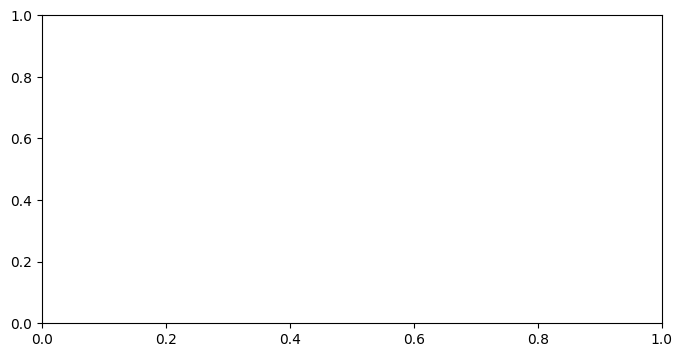

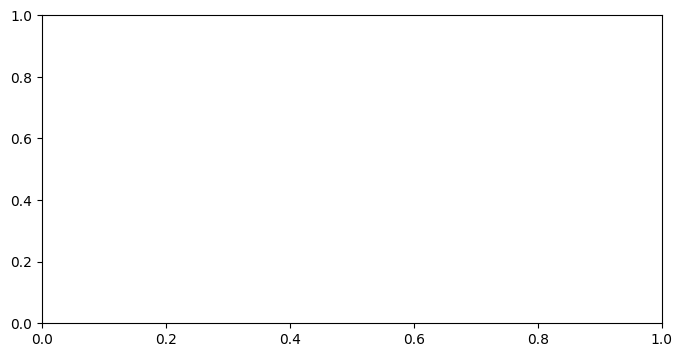

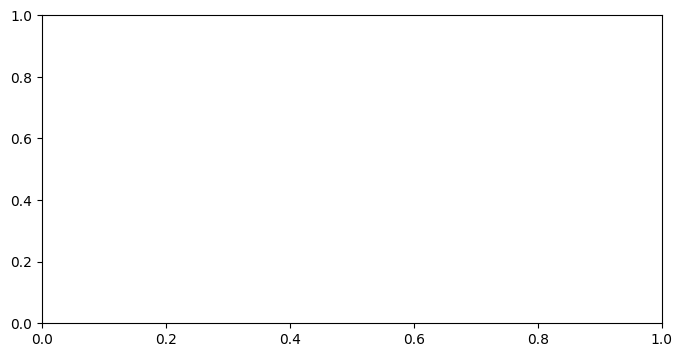

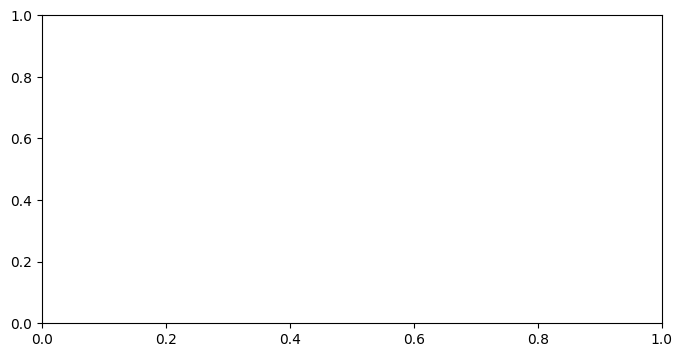

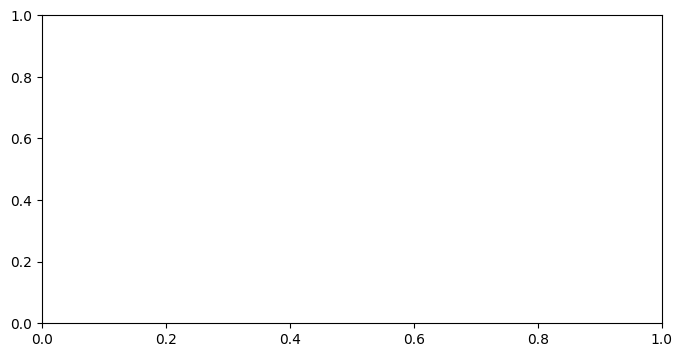

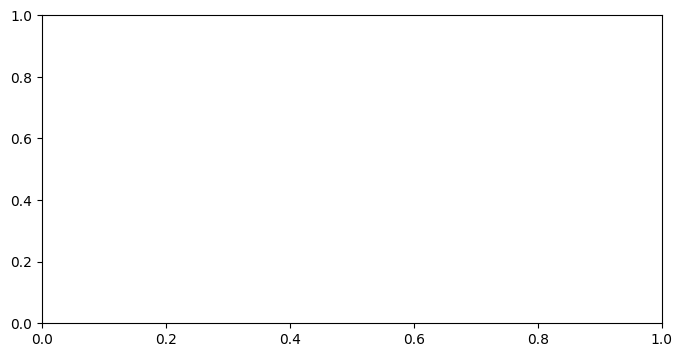

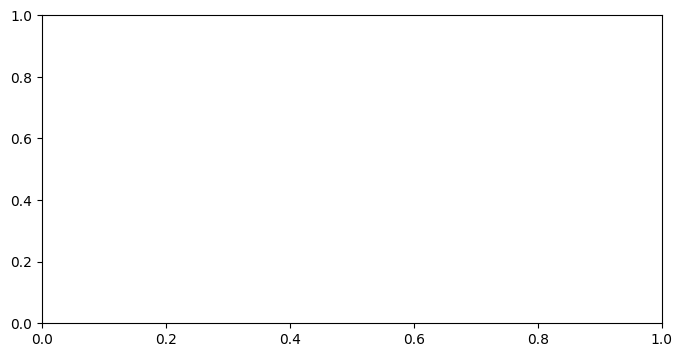

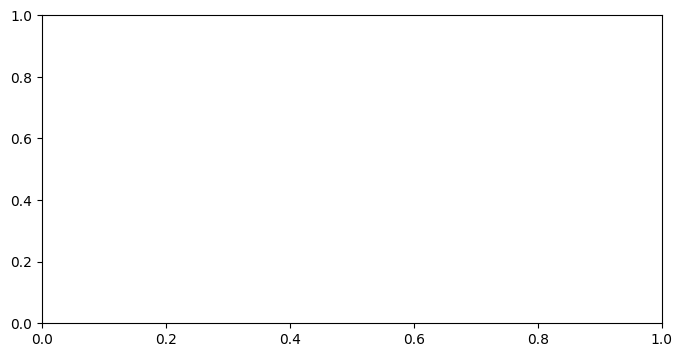

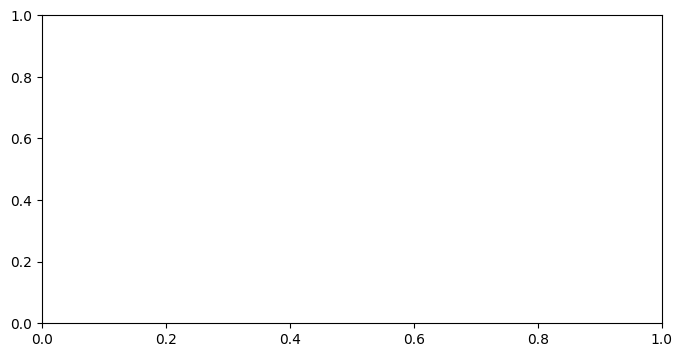

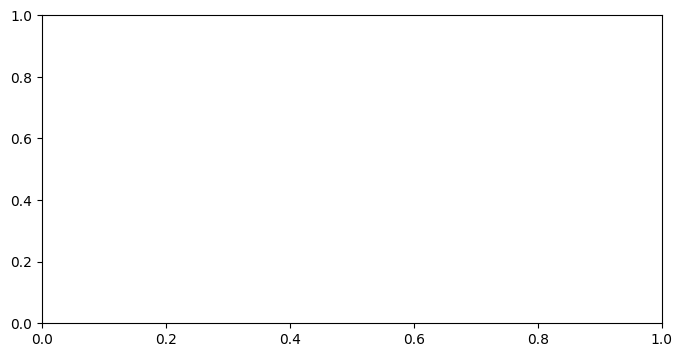

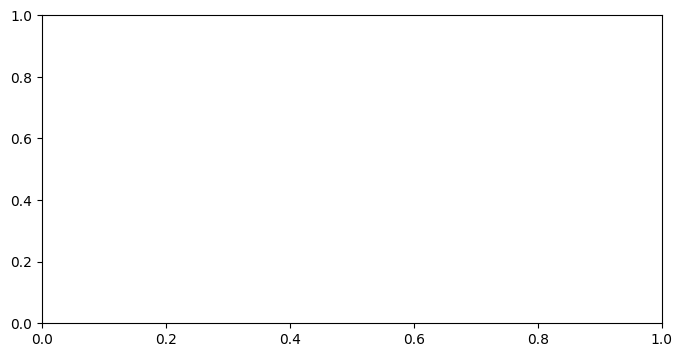

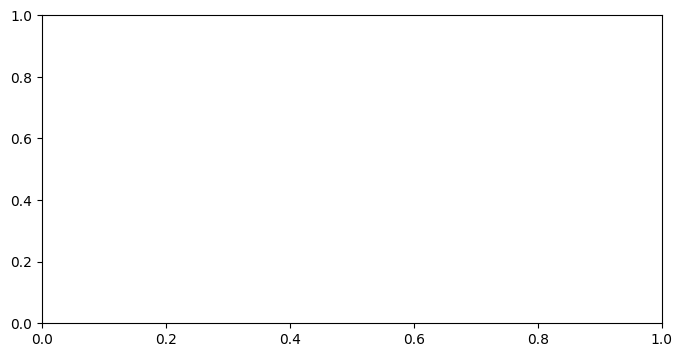

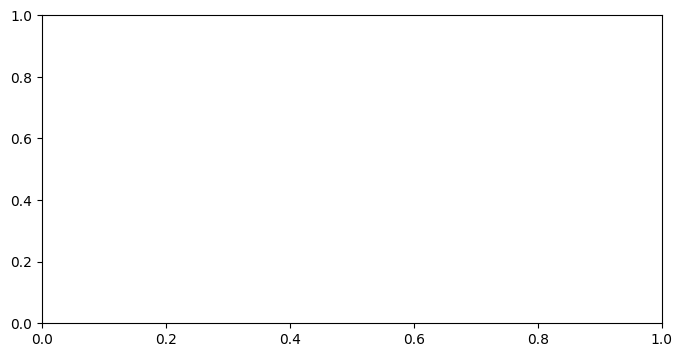

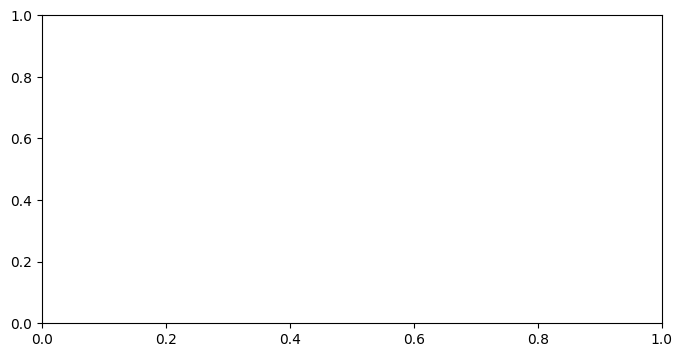

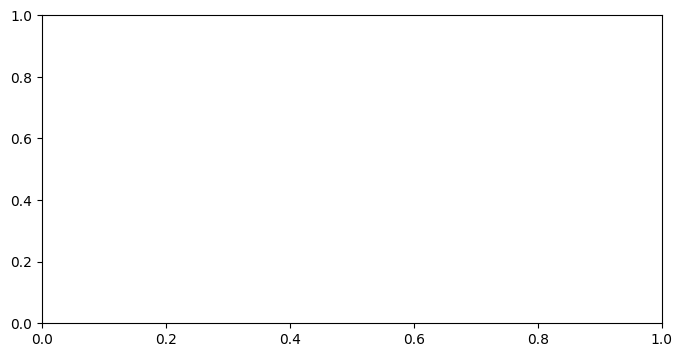

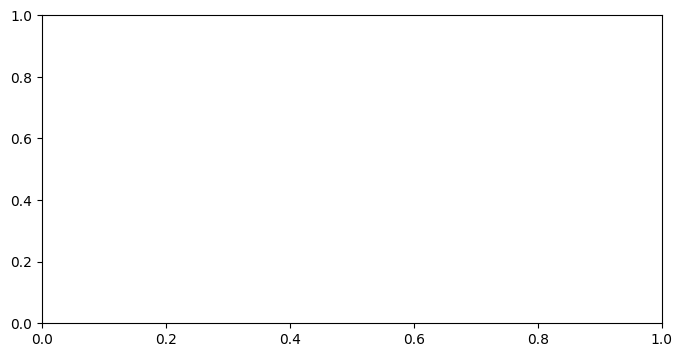

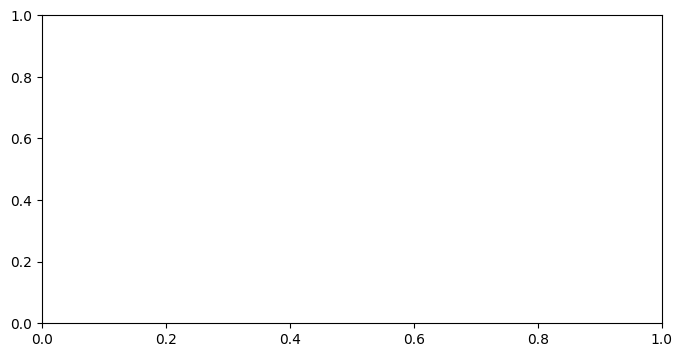

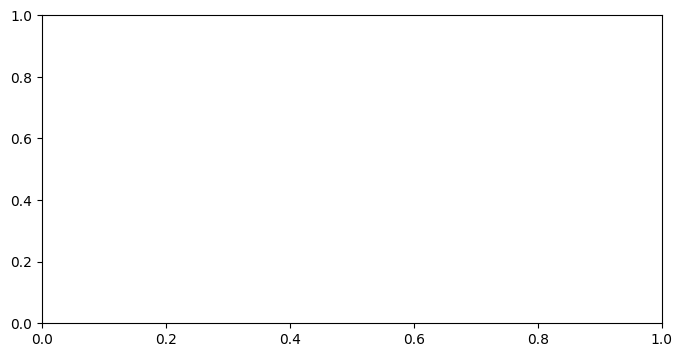

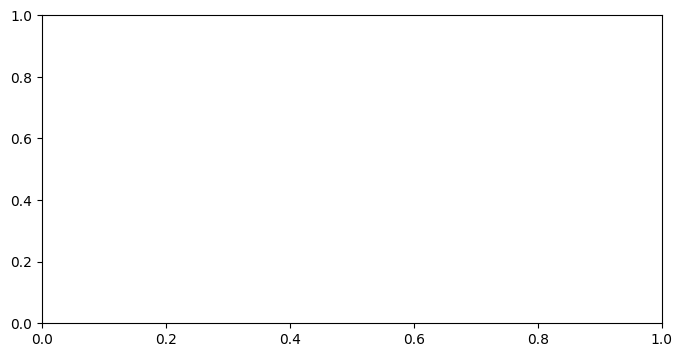

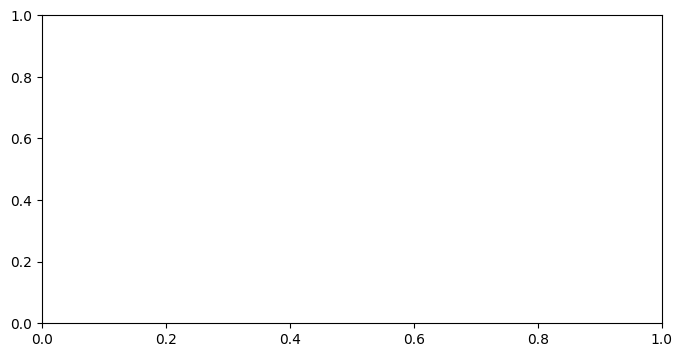

In [7]:
# stats Hilbert pooled across sessions
out_pooled_stats = run_pooled_hilbert_condition_stats(hilbert_stats_cfg)
out_pooled_stats

In [ ]:
# point d'entrée global des stats Hilbert : lance run_pooled_hilbert_condition_stats et/ou run_hilbert_session_condition_stats par session, selon le cfg
summary_hilbert_stats = run_all_hilbert_stats(hilbert_stats_cfg)
summary_hilbert_stats

In [10]:
# lecture des résumés produits
pd.read_json(Path(hilbert_cfg.output_dir) / "run_summary_hilbert.json")
pd.read_json(Path(hilbert_stats_cfg.output_root) / "run_summary_hilbert_stats.json")

ValueError: Mixing dicts with non-Series may lead to ambiguous ordering.